In [1]:
import matplotlib.pyplot as plt

from PAT_fractionally_damped.tutorial_fracPAT_mesh import simulation_times
from WaveNewmarkFractional import *
from scipy.integrate import simps
from scipy.linalg import eigh, solve_triangular, inv
import pickle
import gc
import os
import sys
from utils import *
import numpy as np
from scipy.optimize import minimize
%reload_ext autoreload
%autoreload 2
# Load data as directory
current_directory = os.getcwd()
subfolder = os.path.join(current_directory, 'data')
sys.path.insert(0, subfolder)
plt.rcParams['font.family'] = 'Lato'  # e.g., 'Arial', 'Times New Roman'

Degree of freedom:  2601


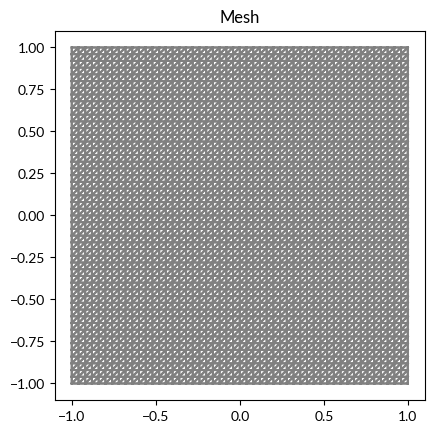

In [2]:
mesh = fn.RectangleMesh(fn.Point(-1, -1), fn.Point(1, 1), 50, 50)
fn.plot(mesh, title='Mesh')
V = fn.FunctionSpace(mesh, 'CG', 1)
print('Degree of freedom: ', V.dim())
u_trial, u_test = fn.TrialFunction(V), fn.TestFunction(V)
M_matrix = fn.assemble(u_trial * u_test * fn.dx)
P_matrix = fn.assemble(u_trial * u_test * fn.dP)
P_solver = Operator2Solver(P_matrix)
fn.plot(mesh)

In [3]:
# Load u_init:
# Initial condition:
class RectangleExpression(fn.UserExpression):
    def eval(self, value, x):
        # Define the boundaries of the smaller L-shape within the square [-0.8, 0.8] x [-0.8, 0.8]
        if x[0] >= -0.55 - fn.DOLFIN_EPS and x[0] <= 0.25 + fn.DOLFIN_EPS and x[1] >= -0.4 - fn.DOLFIN_EPS and x[1] <= 0.125 + fn.DOLFIN_EPS:
            value[0] = 3.0  # Value inside the smaller L-shape
        # Define a circle with radius 0.5 and center (0.1, -0.1)
        # elif (x[0] - 0.25)**2 + (x[1] + 0.125)**2 <= 0.3**2:
        #     value[0] = 3.0  # Value inside the circle
        else:
            value[0] = 0.0  # Value outside the smaller L-shape

    def value_shape(self):
        return ()

ic_expr = RectangleExpression(element=V.ufl_element())
u_init = fn.interpolate(ic_expr, V).vector()
np.save('data/u_init.npy', u_init[:])

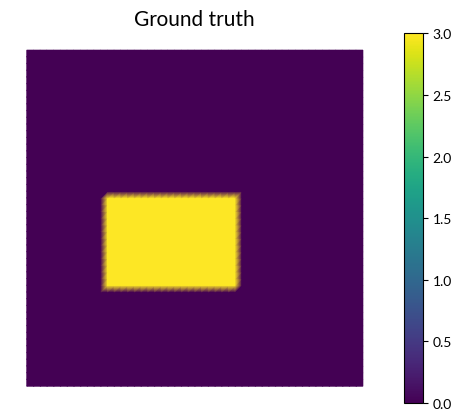

In [14]:
solution = np.load('data/u_init.npy')
u_comp = init_vector_numpy(solution)
m = nb.plot(fn.Function(V, u_comp), colorbar=False)
plt.colorbar(pad = 0.05)
plt.title('Ground truth', fontsize=15)
plt.savefig('plots/u_init.pdf', bbox_inches='tight')
plt.show()

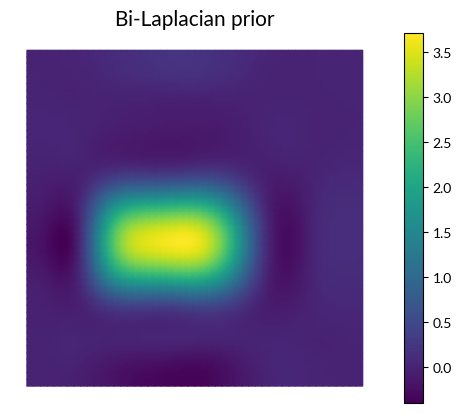

In [20]:
solution = np.load('data/03_100_init_Laplacian.npy')
u_comp = init_vector_numpy(solution)
m = nb.plot(fn.Function(V, u_comp), colorbar=False)
plt.colorbar(pad = 0.05)
plt.title('Bi-Laplacian prior', fontsize=15)
plt.savefig('plots/03_100_init_Laplacian_2.pdf', bbox_inches='tight')
plt.show()

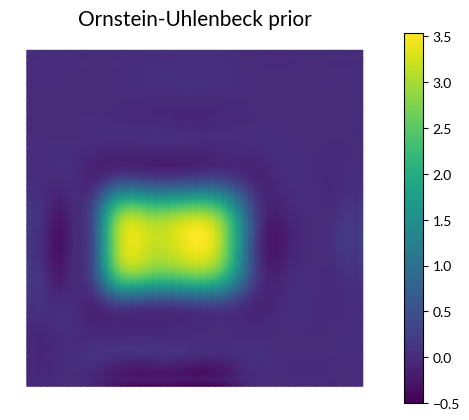

In [21]:
solution = np.load('data/03_100_init_Ornstein.npy')
u_comp = init_vector_numpy(solution)
m = nb.plot(fn.Function(V, u_comp), colorbar=False)
plt.colorbar(pad = 0.05)
plt.title('Ornstein-Uhlenbeck prior', fontsize=15)
plt.savefig('plots/03_100_init_Ornstein_2.pdf', bbox_inches='tight')
plt.show()

In [19]:
# Compute L2 norm of the solution:
solution = np.load('data/08_100_init_Ornstein.npy')
u_init_vec = np.load('data/u_init.npy')
u_init = init_vector_numpy(u_init_vec)
u_comp = init_vector_numpy(solution)
diff = u_comp - u_init
norm = np.sqrt(diff.inner(M_matrix * diff))
norm_zero = np.sqrt(u_init.inner(M_matrix * u_init))
print('L2 norm: ', norm/norm_zero)

L2 norm:  0.5194414935828404


In [6]:
f = lambda x, y:  0.01 * np.exp(-(np.abs(x[0] - y[0]) + np.abs(x[1] - y[1]))/0.1) 
grid = V.tabulate_dof_coordinates()
covariance = comp_covariance(grid, f)
eigvals, eigvecs = np.linalg.eigh(covariance)
eigvals_OU, eigvecs_OI = eigvals[::-1], eigvecs[:, ::-1]

In [7]:
gamma = 1.
delta = 8.
L_form = fn.inner(fn.grad(u_trial), fn.grad(u_test)) * fn.dx
M_form = fn.inner(u_trial, u_test) * fn.dx
R_matrix = fn.assemble(gamma * L_form + delta * M_form)
M_matrix = fn.assemble(M_form)
R_array = R_matrix.array()
M_array = M_matrix.array()
eigvals_R, eigvecs_R = eigh(R_array, M_array)

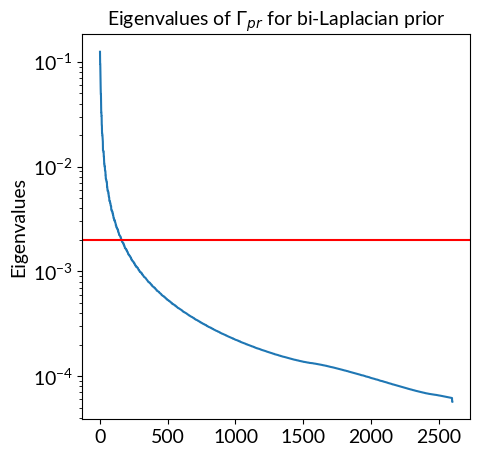

In [8]:
# Plot eigenvalues:
ax_1 = plt.figure(figsize=(5, 5))
plt.semilogy(1/eigvals_R)
plt.ylabel('Eigenvalues', fontsize=14)
plt.title('Eigenvalues of $\Gamma_{pr}$ for bi-Laplacian prior', fontsize=14)
plt.axhline(y=2*1e-3, color='r', linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Export plot to pdf with short marginal:
plt.savefig('plots/eigenvalues_Laplacian.pdf', bbox_inches='tight')

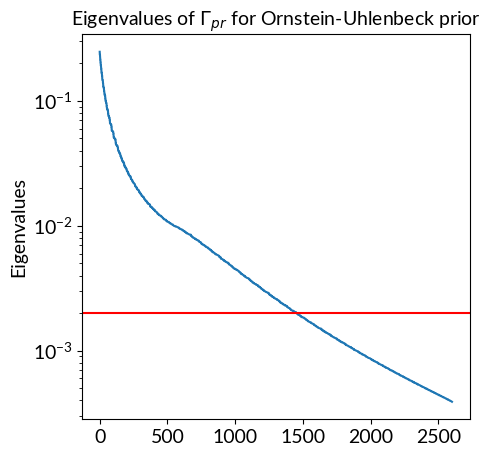

In [10]:
# Plot eigenvalues:
ax_2 = plt.figure(figsize=(5, 5))
plt.semilogy(eigvals_OU)
plt.ylabel('Eigenvalues', fontsize=14)
plt.title('Eigenvalues of $\Gamma_{pr}$ for Ornstein-Uhlenbeck prior', fontsize=14)
plt.axhline(y=2*1e-3, color='r', linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Export plot to pdf with short marginal:
plt.savefig('plots/eigenvalues_Ornstein.pdf', bbox_inches='tight')

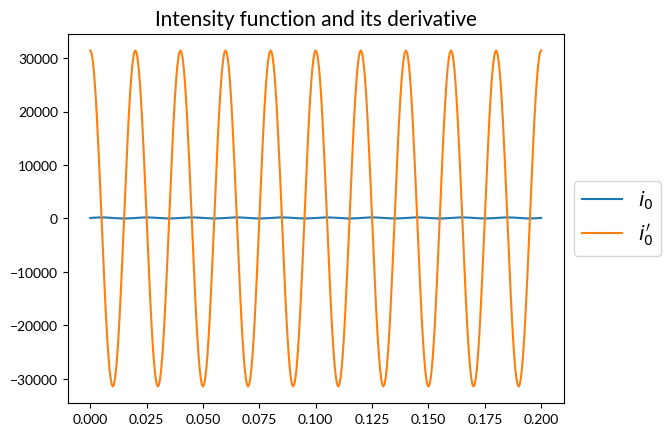

In [12]:
# Plot intensity functions:
T = 0.2
dt = 0.0005
simulation_times = np.arange(0., T + 0.5 * dt, dt)
# Plot i:
i_int_func_time = lambda t: 100 * (np.sin(100 * np.pi * t) + 1)
i_int_time = i_int_func_time(simulation_times)
plt.plot(simulation_times, i_int_time)
# Plot i':
i_prime_func_time = lambda t: 100 * (100 * np.pi * np.cos(100 * np.pi * t))
i_prime_time = i_prime_func_time(simulation_times)
plt.plot(simulation_times, i_prime_time)
# Add bigger legend outside the plot:
plt.legend(['$i_0$', '$i_0\'$'], loc='center left', bbox_to_anchor=(1, 0.5), fontsize='x-large')
# Add title:
plt.title('Intensity function and its derivative', fontsize=15)
# Export plot to pdf with short marginal:
plt.savefig('plots/intensity.pdf', bbox_inches='tight')